In [1]:
import os
import random
import time
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import transforms, datasets
from torch.utils.data import DataLoader

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay
)

In [2]:
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.set_float32_matmul_precision("high")

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("="*50)
print("Device :", device)

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))
    print("CUDA :", torch.version.cuda)

print("="*50)

Device : cuda
GPU : NVIDIA GeForce RTX 3050 6GB Laptop GPU
CUDA : 12.8


In [5]:
IMAGE_SIZE = 224

BATCH_SIZE = 32

EPOCHS = 20

LEARNING_RATE = 1e-4

WEIGHT_DECAY = 1e-4

NUM_WORKERS = 0

NUM_CLASSES = 2

MODEL_SAVE_PATH = "resnet18_cbam_best.pth"

In [6]:
DATA_DIR = "data"

TRAIN_DIR = os.path.join(DATA_DIR, "train")
VAL_DIR = os.path.join(DATA_DIR, "val")
TEST_DIR = os.path.join(DATA_DIR, "test")

In [7]:
train_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.RandomAffine(
        degrees=0,
        translate=(0.05,0.05)
    ),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )

])

In [8]:
val_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )

])

In [9]:
train_dataset = datasets.ImageFolder(
    TRAIN_DIR,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    VAL_DIR,
    transform=val_transform
)

test_dataset = datasets.ImageFolder(
    TEST_DIR,
    transform=val_transform
)

In [10]:
print("="*60)

print("Classes :", train_dataset.classes)

print()

print("Train :", len(train_dataset))
print("Validation :", len(val_dataset))
print("Test :", len(test_dataset))

print("="*60)

Classes : ['Normal', 'Tumor']

Train : 4899
Validation : 1050
Test : 1050


In [11]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

In [12]:
images, labels = next(iter(train_loader))

print("Image Batch Shape :", images.shape)
print("Label Batch Shape :", labels.shape)

print()

print("Unique Labels :", torch.unique(labels))

Image Batch Shape : torch.Size([32, 3, 224, 224])
Label Batch Shape : torch.Size([32])

Unique Labels : tensor([0, 1])


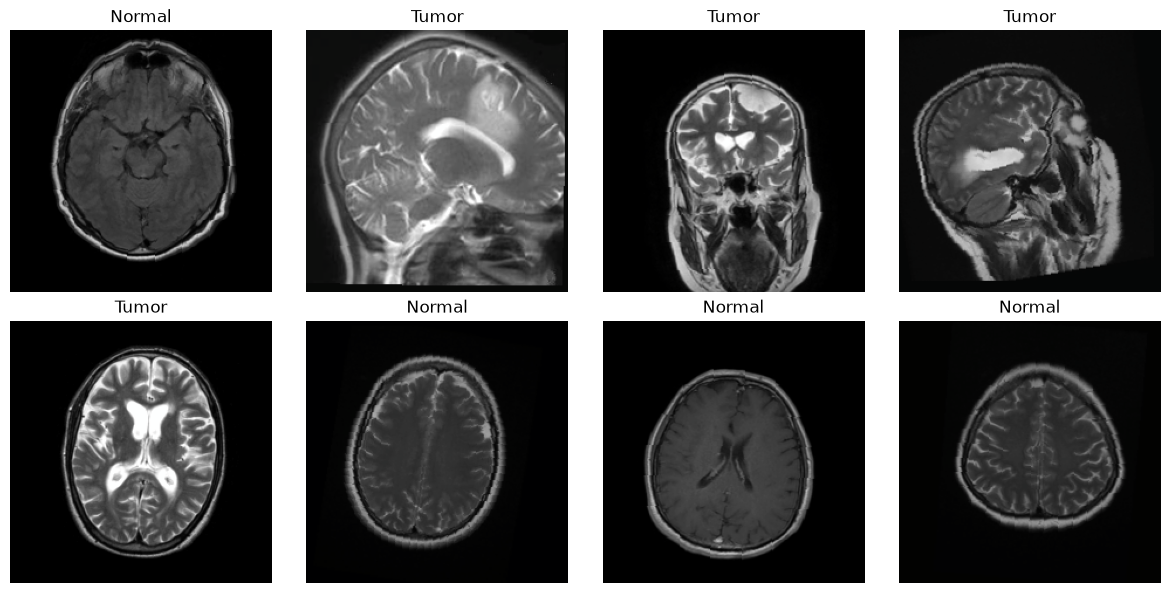

In [13]:
classes = train_dataset.classes

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

images, labels = next(iter(train_loader))

images = images.numpy().transpose(0, 2, 3, 1)

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

images = std * images + mean
images = np.clip(images, 0, 1)

for ax, img, label in zip(axes.flatten(), images[:8], labels[:8]):
    ax.imshow(img)
    ax.set_title(classes[label])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [14]:
def conv3x3(in_channels, out_channels, stride=1):
    return nn.Conv2d(
        in_channels,
        out_channels,
        kernel_size=3,
        stride=stride,
        padding=1,
        bias=False
    )

In [15]:
def conv1x1(in_channels, out_channels, stride=1):
    return nn.Conv2d(
        in_channels,
        out_channels,
        kernel_size=1,
        stride=stride,
        bias=False
    )

In [16]:
import torch.nn as nn

def conv3x3(in_channels, out_channels, stride=1):
    return nn.Conv2d(in_channels, out_channels, 3, stride, 1, bias=False)

def conv1x1(in_channels, out_channels, stride=1):
    return nn.Conv2d(in_channels, out_channels, 1, stride, 0, bias=False)


class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()

        self.conv1 = conv3x3(in_channels, out_channels, stride)
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = conv3x3(out_channels, out_channels)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample

    def forward(self, x):

        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out


class ResNet18(nn.Module):

    def __init__(self, block, layers, num_classes=2):
        super().__init__()

        self.in_channels = 64

        self.conv1 = nn.Conv2d(3, 64, 7, 2, 3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)

        self.maxpool = nn.MaxPool2d(3, 2, 1)

        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, block, out_channels, blocks, stride=1):

        downsample = None

        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                conv1x1(self.in_channels, out_channels, stride),
                nn.BatchNorm2d(out_channels)
            )

        layers = []

        layers.append(
            block(self.in_channels, out_channels, stride, downsample)
        )

        self.in_channels = out_channels

        for _ in range(1, blocks):
            layers.append(
                block(self.in_channels, out_channels)
            )

        return nn.Sequential(*layers)

    def forward(self, x):

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x

In [17]:
def build_resnet18(num_classes=2):
    return ResNet18(BasicBlock, [2, 2, 2, 2], num_classes)

model = build_resnet18(NUM_CLASSES).to(device)

print(model)

ResNet18(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, ker

In [18]:
print(next(model.parameters()).device)

cuda:0


In [19]:
x = torch.randn(2, 3, 224, 224).to(device)

y = model(x)

print("Output shape:", y.shape)

Output shape: torch.Size([2, 2])


In [20]:
class ChannelAttention(nn.Module):

    def __init__(self, in_channels, reduction=16):
        super().__init__()

        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.mlp = nn.Sequential(
            nn.Linear(in_channels, in_channels // reduction, bias=False),
            nn.ReLU(),
            nn.Linear(in_channels // reduction, in_channels, bias=False)
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        b, c, _, _ = x.shape

        avg = self.avg_pool(x).view(b, c)
        max_ = self.max_pool(x).view(b, c)

        avg_out = self.mlp(avg)
        max_out = self.mlp(max_)

        out = avg_out + max_out
        out = self.sigmoid(out).view(b, c, 1, 1)

        return x * out

In [21]:
class SpatialAttention(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv = nn.Conv2d(
            2, 1,
            kernel_size=7,
            padding=3,
            bias=False
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)

        x_cat = torch.cat([avg_out, max_out], dim=1)

        attention = self.conv(x_cat)
        attention = self.sigmoid(attention)

        return x * attention

In [22]:
class CBAM(nn.Module):

    def __init__(self, channels, reduction=16):
        super().__init__()

        self.channel_attention = ChannelAttention(channels, reduction)
        self.spatial_attention = SpatialAttention()

    def forward(self, x):

        x = self.channel_attention(x)
        x = self.spatial_attention(x)

        return x

In [23]:
class BasicBlockCBAM(nn.Module):

    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()

        self.conv1 = conv3x3(in_channels, out_channels, stride)
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = conv3x3(out_channels, out_channels)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.cbam = CBAM(out_channels)

        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample

    def forward(self, x):

        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out = self.cbam(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out

In [24]:
class ResNet18CBAM(nn.Module):

    def __init__(self, block, layers, num_classes=2):
        super().__init__()

        self.in_channels = 64

        self.conv1 = nn.Conv2d(3, 64, 7, 2, 3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)

        self.maxpool = nn.MaxPool2d(3, 2, 1)

        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, block, out_channels, blocks, stride=1):

        downsample = None

        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                conv1x1(self.in_channels, out_channels, stride),
                nn.BatchNorm2d(out_channels)
            )

        layers = []

        layers.append(
            block(self.in_channels, out_channels, stride, downsample)
        )

        self.in_channels = out_channels

        for _ in range(1, blocks):
            layers.append(
                block(self.in_channels, out_channels)
            )

        return nn.Sequential(*layers)

    def forward(self, x):

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x

In [25]:
def build_model():
    return ResNet18CBAM(
        BasicBlockCBAM,
        [2, 2, 2, 2],
        NUM_CLASSES
    )

model = build_model().to(device)

print(model)

ResNet18CBAM(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlockCBAM(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (cbam): CBAM(
        (channel_attention): ChannelAttention(
          (avg_pool): AdaptiveAvgPool2d(output_size=1)
          (max_pool): AdaptiveMaxPool2d(output_size=1)
          (mlp): Sequential(
            (0): Linear(in_features=64, out_features=4, bias=Fals

In [26]:
x = torch.randn(2, 3, 224, 224).to(device)

y = model(x)

print("Output shape:", y.shape)

Output shape: torch.Size([2, 2])


In [27]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.5
)

In [28]:
scaler = torch.cuda.amp.GradScaler()

C:\Users\utkar\AppData\Local\Temp\ipykernel_20960\2340218076.py:1: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [29]:
def accuracy(outputs, labels):
    _, preds = torch.max(outputs, 1)
    correct = (preds == labels).sum().item()
    return correct / labels.size(0)

In [30]:
def train_one_epoch(model, loader, optimizer, criterion):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        # ⚡ AMP forward pass
        with torch.cuda.amp.autocast():

            outputs = model(images)
            loss = criterion(outputs, labels)

        # ⚡ backward scaled
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / len(loader), correct / total

In [31]:
def validate(model, loader, criterion):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.cuda.amp.autocast():

                outputs = model(images)
                loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return running_loss / len(loader), correct / total

In [32]:
best_acc = 0.0
history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

for epoch in range(EPOCHS):

    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")

    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion
    )

    val_loss, val_acc = validate(
        model, val_loader, criterion
    )

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

    # Save best model
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print("✅ Best model saved!")

print("\nTraining Complete!")
print("Best Validation Accuracy:", best_acc)


Epoch [1/20]


C:\Users\utkar\AppData\Local\Temp\ipykernel_20960\2648980655.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
C:\Users\utkar\AppData\Local\Temp\ipykernel_20960\3210275419.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Train Loss: 0.1766 | Train Acc: 0.9294
Val   Loss: 0.1224 | Val   Acc: 0.9514
✅ Best model saved!

Epoch [2/20]
Train Loss: 0.0732 | Train Acc: 0.9726
Val   Loss: 0.0269 | Val   Acc: 0.9924
✅ Best model saved!

Epoch [3/20]
Train Loss: 0.0547 | Train Acc: 0.9806
Val   Loss: 0.0429 | Val   Acc: 0.9886

Epoch [4/20]
Train Loss: 0.0561 | Train Acc: 0.9845
Val   Loss: 0.0162 | Val   Acc: 0.9952
✅ Best model saved!

Epoch [5/20]
Train Loss: 0.0592 | Train Acc: 0.9782
Val   Loss: 0.0116 | Val   Acc: 0.9971
✅ Best model saved!

Epoch [6/20]
Train Loss: 0.0302 | Train Acc: 0.9884
Val   Loss: 0.0145 | Val   Acc: 0.9962

Epoch [7/20]
Train Loss: 0.0226 | Train Acc: 0.9918
Val   Loss: 0.0121 | Val   Acc: 0.9943

Epoch [8/20]
Train Loss: 0.0195 | Train Acc: 0.9931
Val   Loss: 0.0138 | Val   Acc: 0.9962

Epoch [9/20]
Train Loss: 0.0181 | Train Acc: 0.9943
Val   Loss: 0.0095 | Val   Acc: 0.9981
✅ Best model saved!

Epoch [10/20]
Train Loss: 0.0160 | Train Acc: 0.9933
Val   Loss: 0.0181 | Val   Acc: 

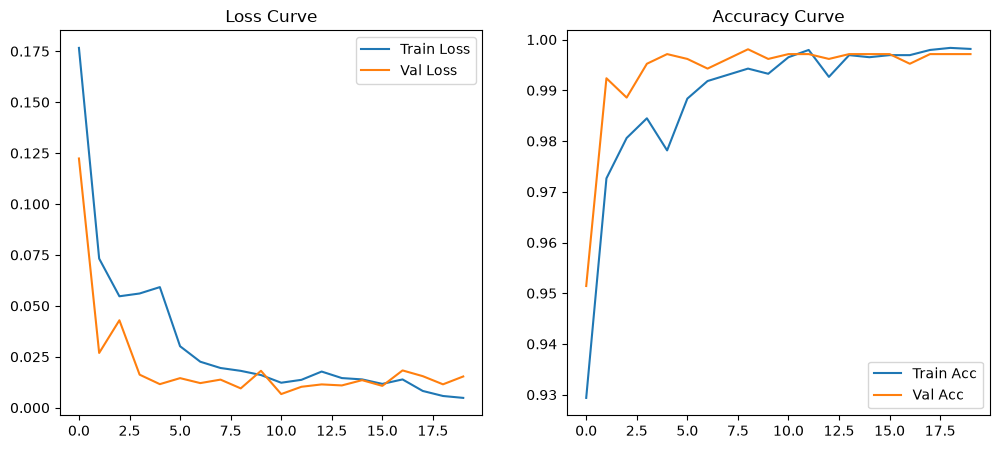

In [33]:
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss Curve")

# Accuracy
plt.subplot(1,2,2)
plt.plot(history["train_acc"], label="Train Acc")
plt.plot(history["val_acc"], label="Val Acc")
plt.legend()
plt.title("Accuracy Curve")

plt.show()

In [34]:
model.load_state_dict(torch.load(MODEL_SAVE_PATH))
model = model.to(device)
model.eval()

print("Best model loaded!")

Best model loaded!


In [35]:
all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [36]:
acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds)
rec = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)

print("="*50)
print("TEST RESULTS")
print("="*50)

print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1 Score :", f1)

TEST RESULTS
Accuracy : 0.9933333333333333
Precision: 0.9876288659793815
Recall   : 0.9979166666666667
F1 Score : 0.9927461139896373


In [37]:
print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))

              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99       570
       Tumor       0.99      1.00      0.99       480

    accuracy                           0.99      1050
   macro avg       0.99      0.99      0.99      1050
weighted avg       0.99      0.99      0.99      1050



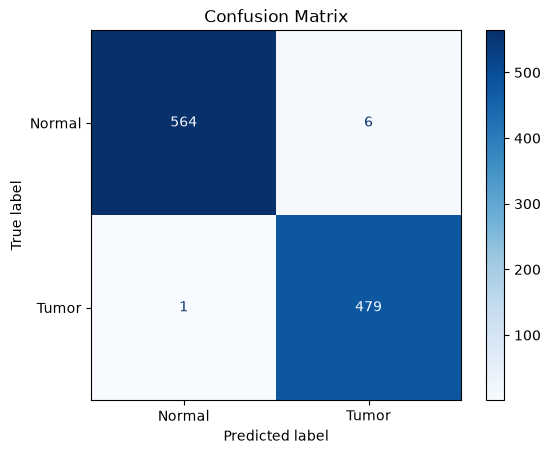

In [38]:
cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=train_dataset.classes
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [39]:
import os

RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

print("Results will be saved to:", RESULTS_DIR)

Results will be saved to: results


In [40]:
import pandas as pd

history_df = pd.DataFrame(history)

history_df.to_csv(
    os.path.join(RESULTS_DIR, "training_history.csv"),
    index=False
)

print("Training history saved.")

Training history saved.


In [ ]:
report = classification_report(
    all_labels,
    all_preds,
    target_names=train_dataset.classes,
    digits=4
)

with open(os.path.join(RESULTS_DIR, "classification_report.txt"), "w") as f:
    f.write(report)

print(report)

              precision    recall  f1-score   support

      Normal     0.9982    0.9895    0.9938       570
       Tumor     0.9876    0.9979    0.9927       480

    accuracy                         0.9933      1050
   macro avg     0.9929    0.9937    0.9933      1050
weighted avg     0.9934    0.9933    0.9933      1050



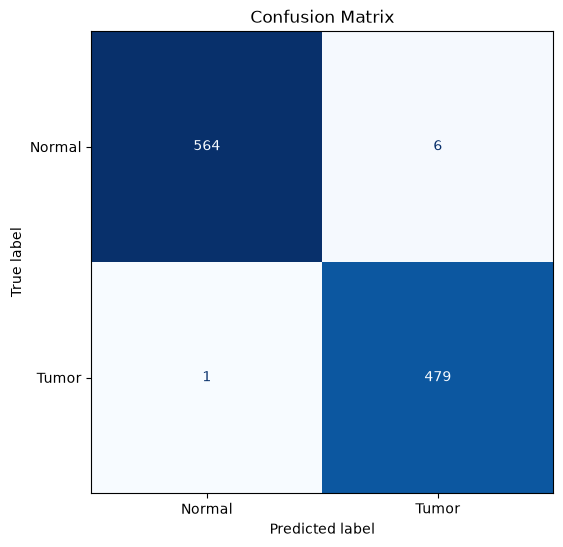

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=train_dataset.classes
)

fig, ax = plt.subplots(figsize=(6,6))

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False,
    values_format="d"
)

plt.title("Confusion Matrix")

plt.savefig(
    os.path.join(RESULTS_DIR, "confusion_matrix.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

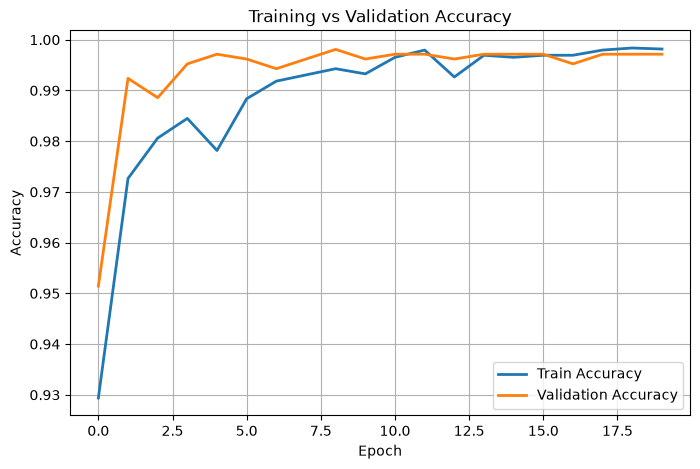

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history["train_acc"], label="Train Accuracy", linewidth=2)
plt.plot(history["val_acc"], label="Validation Accuracy", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.grid(True)
plt.legend()

plt.savefig(
    os.path.join(RESULTS_DIR, "accuracy_curve.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()